# Preparation

In [ ]:
import os
import sys

# Go up one directory level to the project root folder
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can successfully import from your module folder


In [1]:
from module.DepthConstSet import DepthConstSet
from module.NyuDatasetV2 import *
from module.MLModel import SwinTransformerPretrained
from module.Training import train_model, plot_metrics, test_model

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt # For visualization


/home/dragauler/code_env/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Ensure reproducibility for consistent results
torch.manual_seed(42)
np.random.seed(42)

# Define the path to your NYU Depth V2 labeled dataset (.mat file).
# You MUST replace this with the actual path on your system.
# The dataset can typically be downloaded from the official NYU Depth V2 website
# or other academic sources.
NYU_DATASET_PATH = 'nyu_depth_v2_labeled.mat' 
nyuv2_path = project_root + "/module/nyuv2_python_toolkit_master/NYUv2"

# Define the number of classes for segmentation.
# For NYU Depth V2, a common setup uses 40 semantic classes + 1 for unlabeled/background (label 0).
# So, total classes = 41.
NUM_CLASSES = 13
BATCH_SIZE = 4
LR=1e-4
# LR=5e-4
WEIGHT_DECAY=1e-3

# Define the target image size for resizing. NYU images are 480x640.
# Downsampling can speed up training.
# IMAGE_SIZE = (240, 320) 
# IMAGE_SIZE = (480, 640) 
IMAGE_SIZE = (480, 480) 

EPOCH = 50
MULTI_STEP = [20,40]

In [3]:
# Set the device for training (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Load dataset

## Set Dataloader

In [4]:
train_loader, val_loader, test_loader = get_train_val_dataloaders(
    dataset_path=nyuv2_path,
    batch_size=BATCH_SIZE,         # Small batch size for demonstration; increase for real training
    image_size=IMAGE_SIZE,
    transform_depth = False
)

Dataset loaded. Total samples: 795
Train samples: 636, Validation samples: 40, Test samples: 164


In [5]:
first_batch = next(iter(train_loader))
# image, (depth, label) = first_batch
(img, depthDict, GT) = first_batch

In [6]:
depthDict.keys()

dict_keys(['raw'])

In [7]:
depthDict[DepthConstSet().raw].shape

torch.Size([4, 1, 480, 480])

In [8]:
GT.shape

torch.Size([4, 13, 480, 480])

# Visualize dataset

In [9]:
# --- Visualize a batch from the train_loader ---
print("\nVisualizing a batch from the training DataLoader...")
# Get one batch
# first_batch = next(iter(train_loader))



Visualizing a batch from the training DataLoader...


In [10]:
# Categories
# train_loader.dataset.dataset.__getLabelList__()

In [11]:
(rgb_images, depth_maps, labels) = first_batch

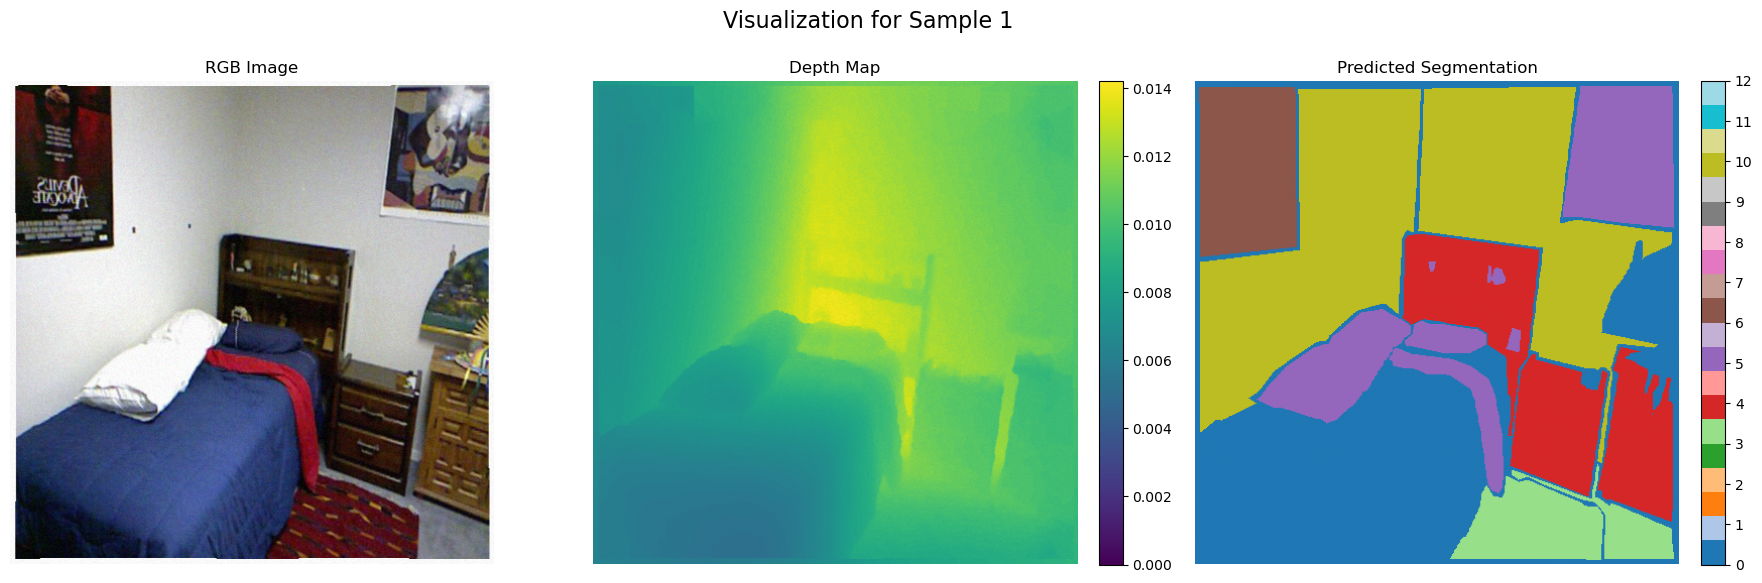

Channel 0: 0.0
Channel 1: 0.0
Channel 2: 0.0
Channel 3: 1.0
Channel 4: 1.0
Channel 5: 1.0
Channel 6: 1.0
Channel 7: 0.0
Channel 8: 0.0
Channel 9: 0.0
Channel 10: 1.0
Channel 11: 0.0
Channel 12: 0.0


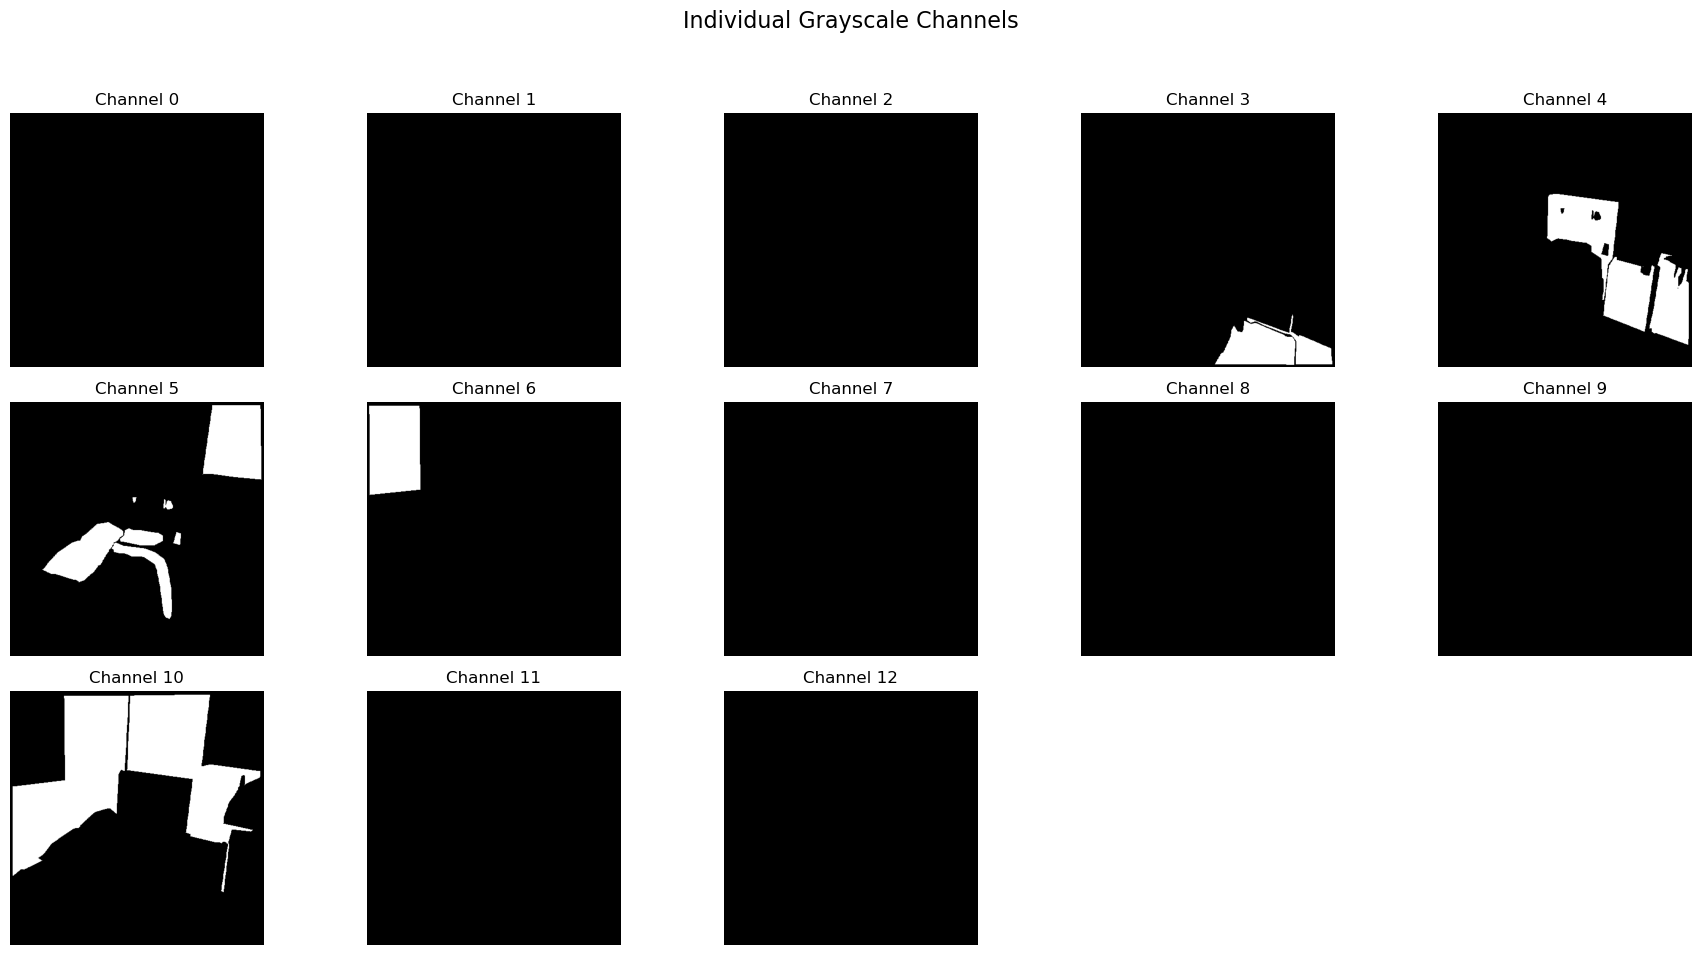

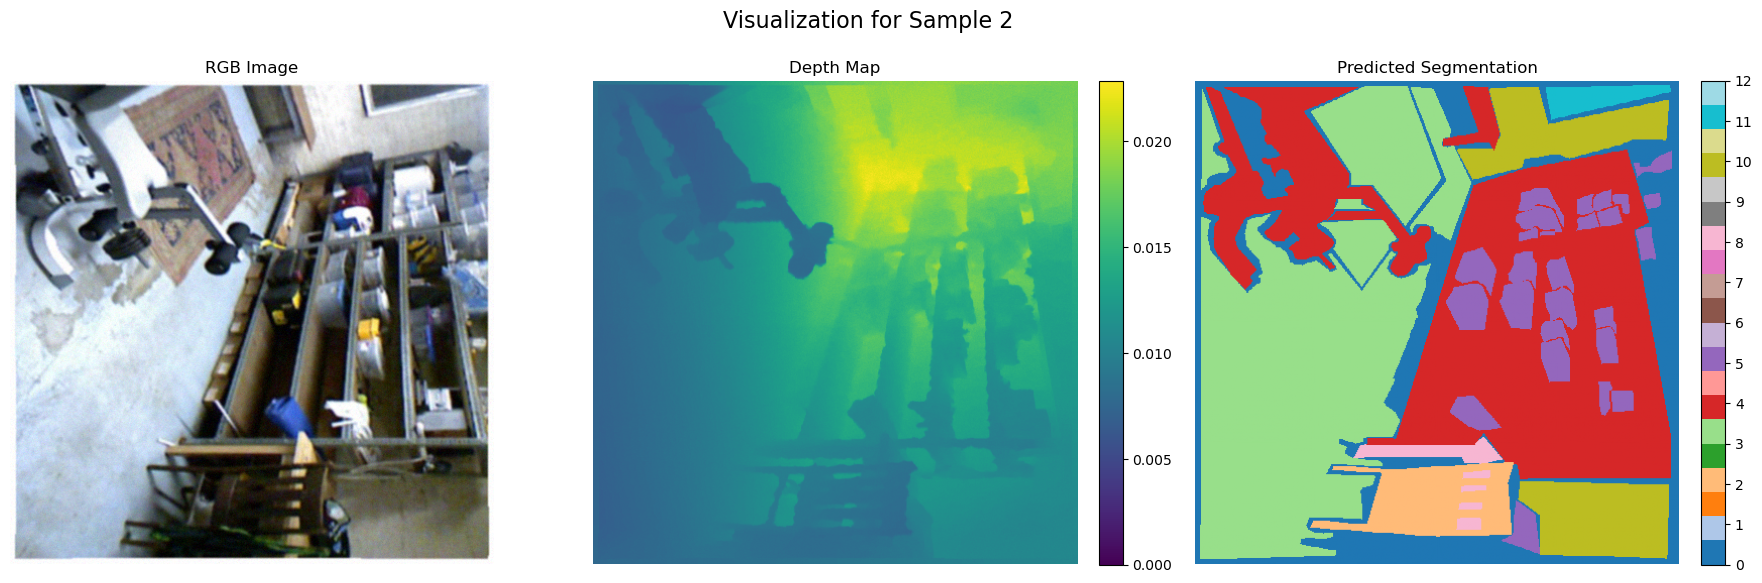

Channel 0: 0.0
Channel 1: 0.0
Channel 2: 1.0
Channel 3: 1.0
Channel 4: 1.0
Channel 5: 1.0
Channel 6: 0.0
Channel 7: 0.0
Channel 8: 1.0
Channel 9: 0.0
Channel 10: 1.0
Channel 11: 1.0
Channel 12: 0.0


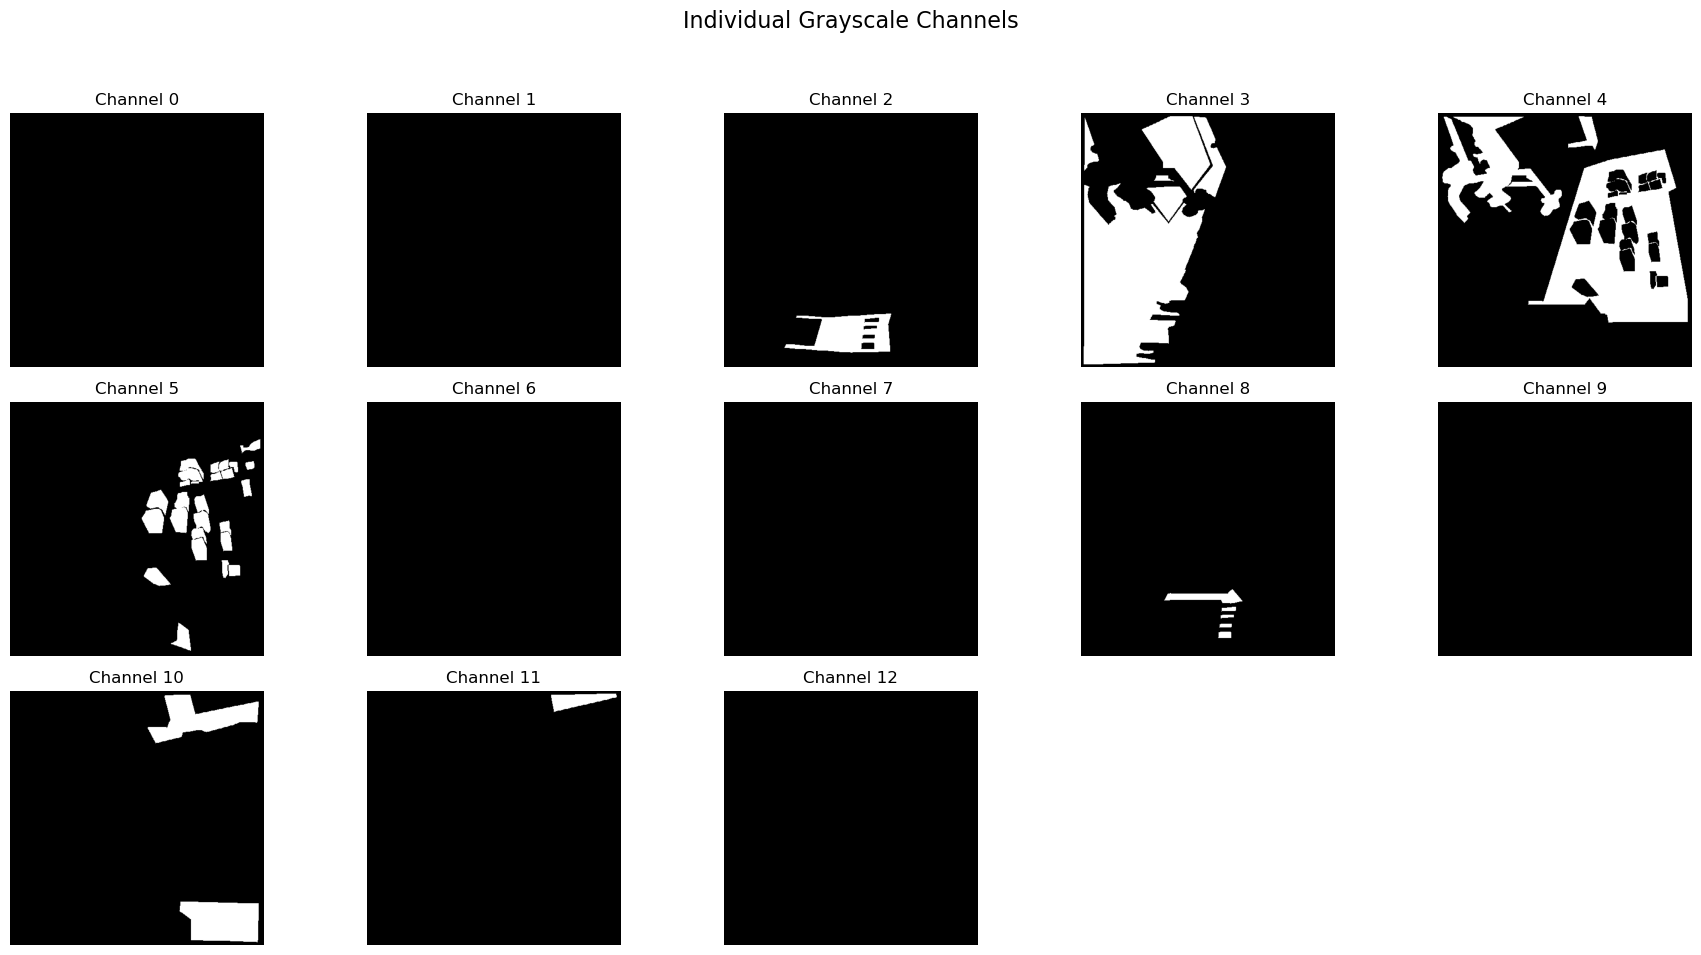

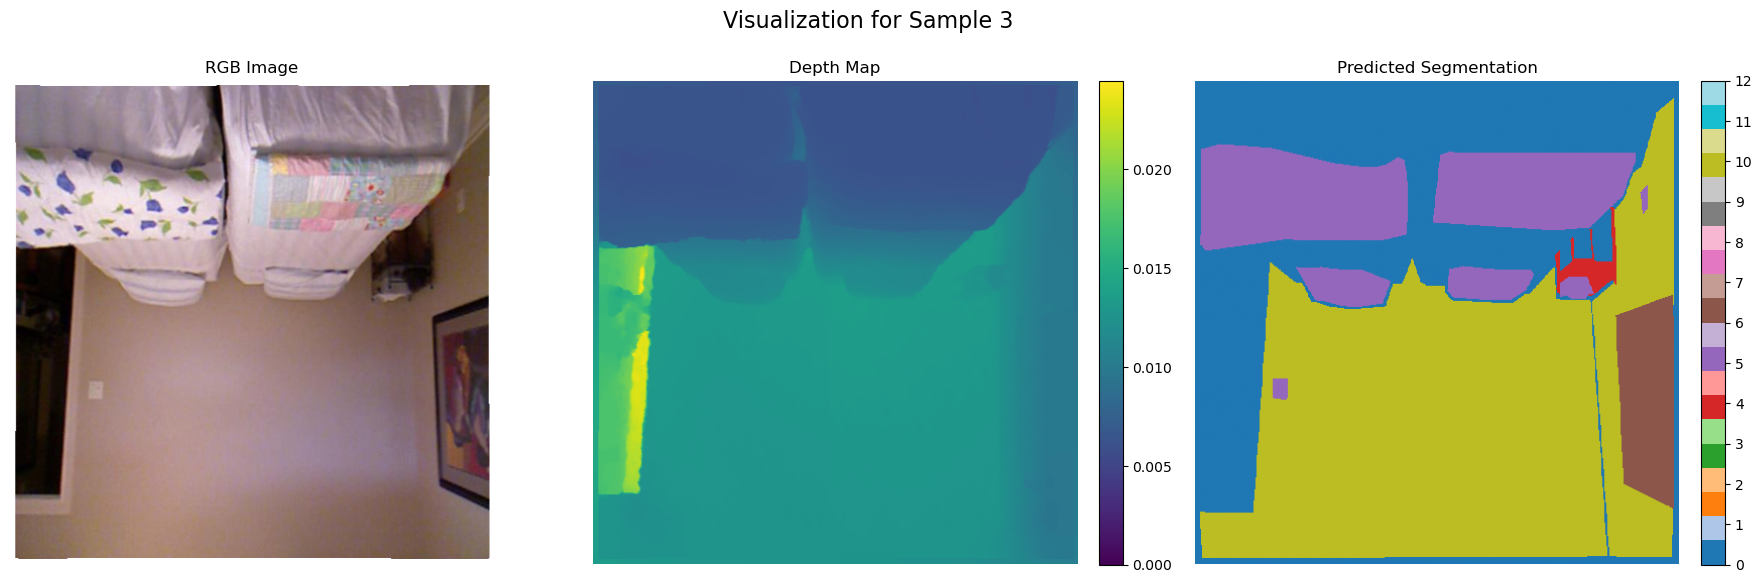

Channel 0: 0.0
Channel 1: 0.0
Channel 2: 0.0
Channel 3: 0.0
Channel 4: 1.0
Channel 5: 1.0
Channel 6: 1.0
Channel 7: 0.0
Channel 8: 0.0
Channel 9: 0.0
Channel 10: 1.0
Channel 11: 0.0
Channel 12: 0.0


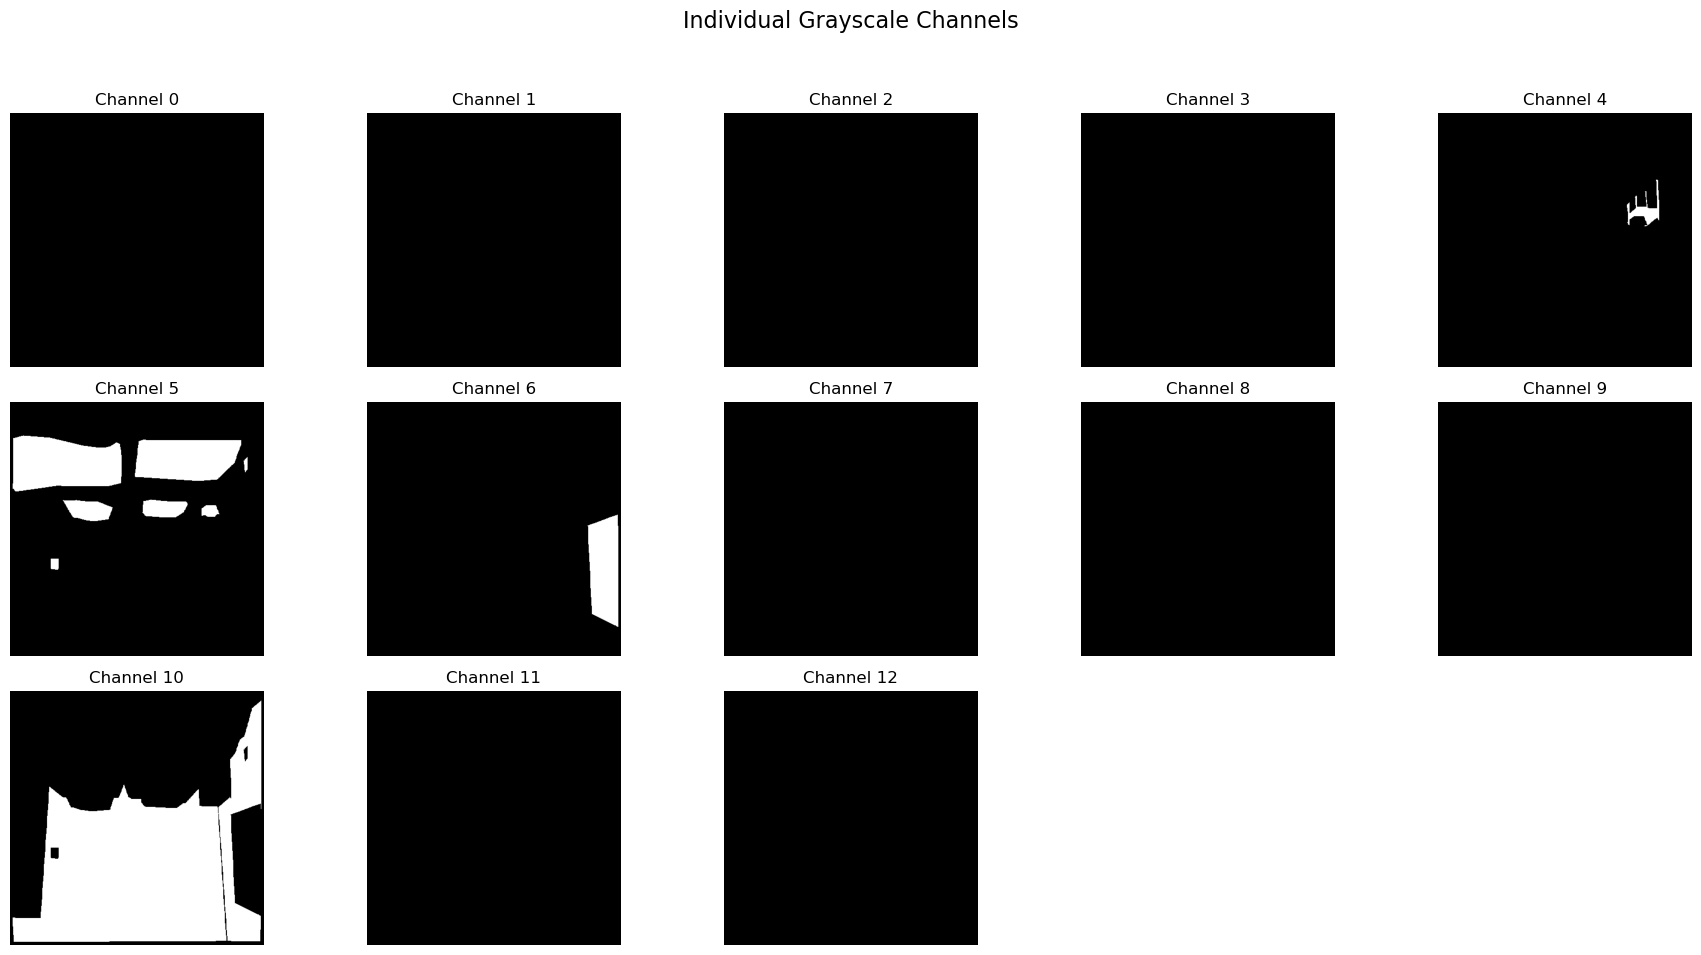

Visualization complete. A plot window should have appeared.


In [12]:
# To denormalize RGB images correctly, we need access to the NyuDataset instance's
# mean and std. We can get this from the `dataset` attribute of the DataLoader's
# `dataset` attribute (which is a Subset object from random_split).
# The `dataset` attribute of the `Subset` object holds the original `NyuDataset`.

visualize_batch(first_batch, NUM_CLASSES, transform_depth=False)
print("Visualization complete. A plot window should have appeared.")
# --- End Visualization ---


# Model

In [13]:
modelName = "SwinTransformer"
in_channel=3
modelRaw = SwinTransformerPretrained(in_channels=in_channel, num_classes=NUM_CLASSES)
modelRaw.eval()

[transformers] You passed `num_labels=13` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100%|██████████| 511/511 [00:00<00:00, 2026.76it/s]
[transformers] UperNetForSemanticSegmentation LOAD REPORT from: openmmlab/upernet-swin-large
Key                              | Status   |                                                                                                      
---------------------------------+----------+------------------------------------------------------------------------------------------------------
auxiliary_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([13])                      
decode_head.classifier.weight    | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 512, 1, 1]) vs model:torch.Size([13, 512, 1, 1])
auxiliary_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([13, 256, 1,

SwinTransformerPretrained(
  (model): UperNetForSemanticSegmentation(
    (backbone): SwinBackbone(
      (swin): SwinModel(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (attention): SwinAttention(
                    (q_proj): Linear(in_features=192, out_features=192, bias=True)
                    (k_proj): Linear(in_features=192, out_features=192, bias=True)
                    (v_proj): Linear(in_features=192, out_features=192, bias=True)
                    (o_proj): Linear(in_features=192, out_features=192, bias=True)
                    (relati

In [14]:
x = torch.randn((BATCH_SIZE, in_channel, IMAGE_SIZE[0], IMAGE_SIZE[1]))
# model = UNetModel(in_channels=4, num_classes=NUM_CLASSES)
with torch.no_grad():
    outputs = modelRaw(x)
# logits = outputs.logits  # [B, num_classes, h, w]


In [15]:
print(f"x shape: {x.shape}")
print(f"pred shape: {outputs.shape}")
predShape=torch.Size([BATCH_SIZE, NUM_CLASSES, IMAGE_SIZE[0], IMAGE_SIZE[1]])
print(f"expected shape: {predShape}")
assert outputs.shape == predShape

x shape: torch.Size([4, 3, 480, 480])
pred shape: torch.Size([4, 13, 480, 480])
expected shape: torch.Size([4, 13, 480, 480])


# Training Depth Raw

## Training

In [16]:
model_save_path = modelName + "_depth_segmentation_RGB.pth" # Define path for saved model# NUM_CLASSES=14
train_losses, train_accuracies, train_mious, val_losses, val_accuracies, val_mious = train_model(
    model=modelRaw,
    train_dataloader=train_loader,
    val_dataloader=val_loader, 
    num_classes=NUM_CLASSES,
    epochs=EPOCH, # Small number of epochs for demonstration; increase for actual training
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    # multi_step_list=MULTI_STEP,
    device=device,
    model_save_path=model_save_path,
    RGB_ToTrain=True,
    PD_ToTrain = DepthConstSet().raw
)

Training started on cuda for 50 epochs.
Epoch [1/50], Batch [15/159], Train Loss: 1.8013, Train Acc (current): 0.2312, Train mIoU (current): 0.0700
Epoch [1/50], Batch [30/159], Train Loss: 1.5619, Train Acc (current): 0.3310, Train mIoU (current): 0.1233
Epoch [1/50], Batch [45/159], Train Loss: 1.3869, Train Acc (current): 0.3884, Train mIoU (current): 0.1622
Epoch [1/50], Batch [60/159], Train Loss: 1.2709, Train Acc (current): 0.4140, Train mIoU (current): 0.1753
Epoch [1/50], Batch [75/159], Train Loss: 1.1817, Train Acc (current): 0.4371, Train mIoU (current): 0.1971
Epoch [1/50], Batch [90/159], Train Loss: 1.1268, Train Acc (current): 0.4566, Train mIoU (current): 0.2113
Epoch [1/50], Batch [105/159], Train Loss: 1.0743, Train Acc (current): 0.4741, Train mIoU (current): 0.2234
Epoch [1/50], Batch [120/159], Train Loss: 1.0200, Train Acc (current): 0.4907, Train mIoU (current): 0.2377
Epoch [1/50], Batch [135/159], Train Loss: 0.9760, Train Acc (current): 0.5048, Train mIoU (cu


--- Plotting Training and Validation Metrics ---


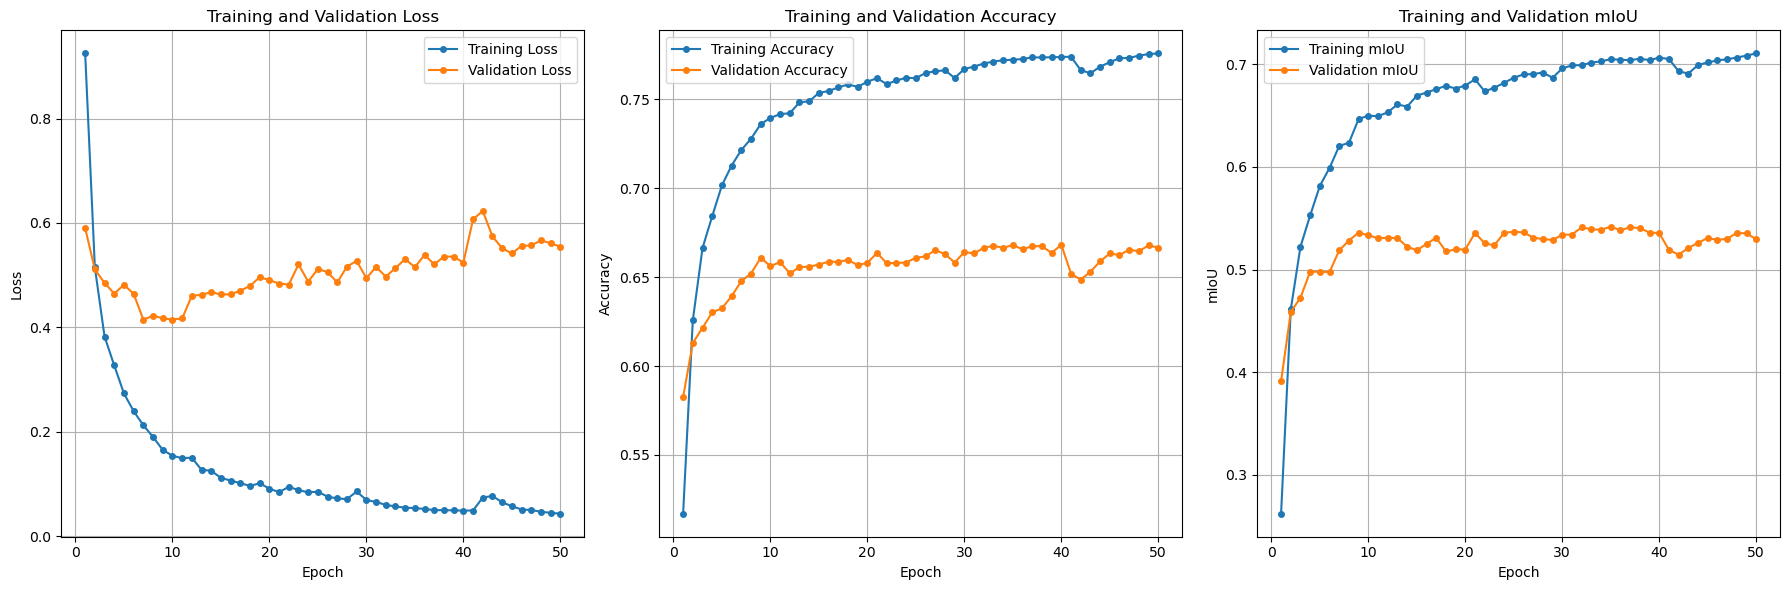

Metric plots generated.


In [17]:
# Plot the collected metrics after training
print("\n--- Plotting Training and Validation Metrics ---")
plot_metrics(train_losses, train_accuracies, train_mious, 
                val_losses, val_accuracies, val_mious, epochs=EPOCH)
print("Metric plots generated.")

## Testing


--- Running Test Model ---
Loaded model from SwinTransformer_depth_segmentation_RGB.pth

Starting model testing and visualization...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


(4, 480, 480)


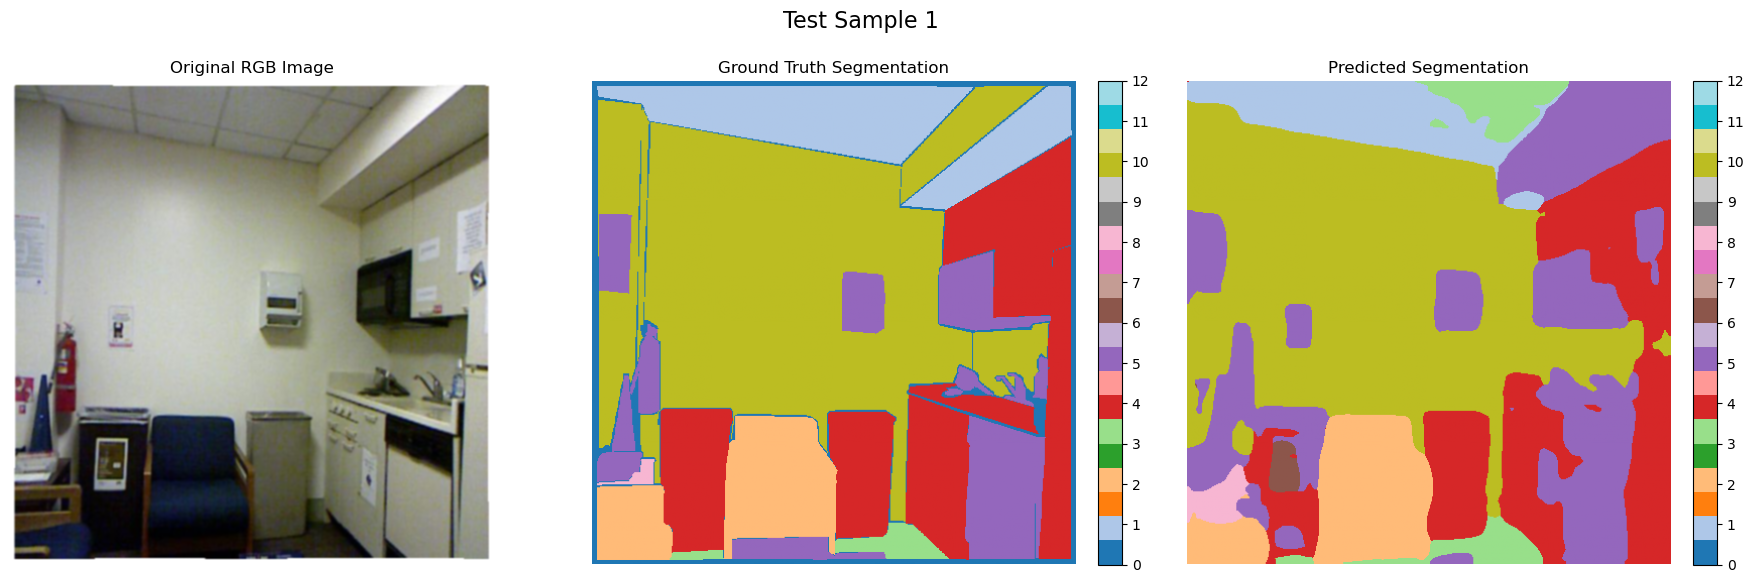

(4, 480, 480)


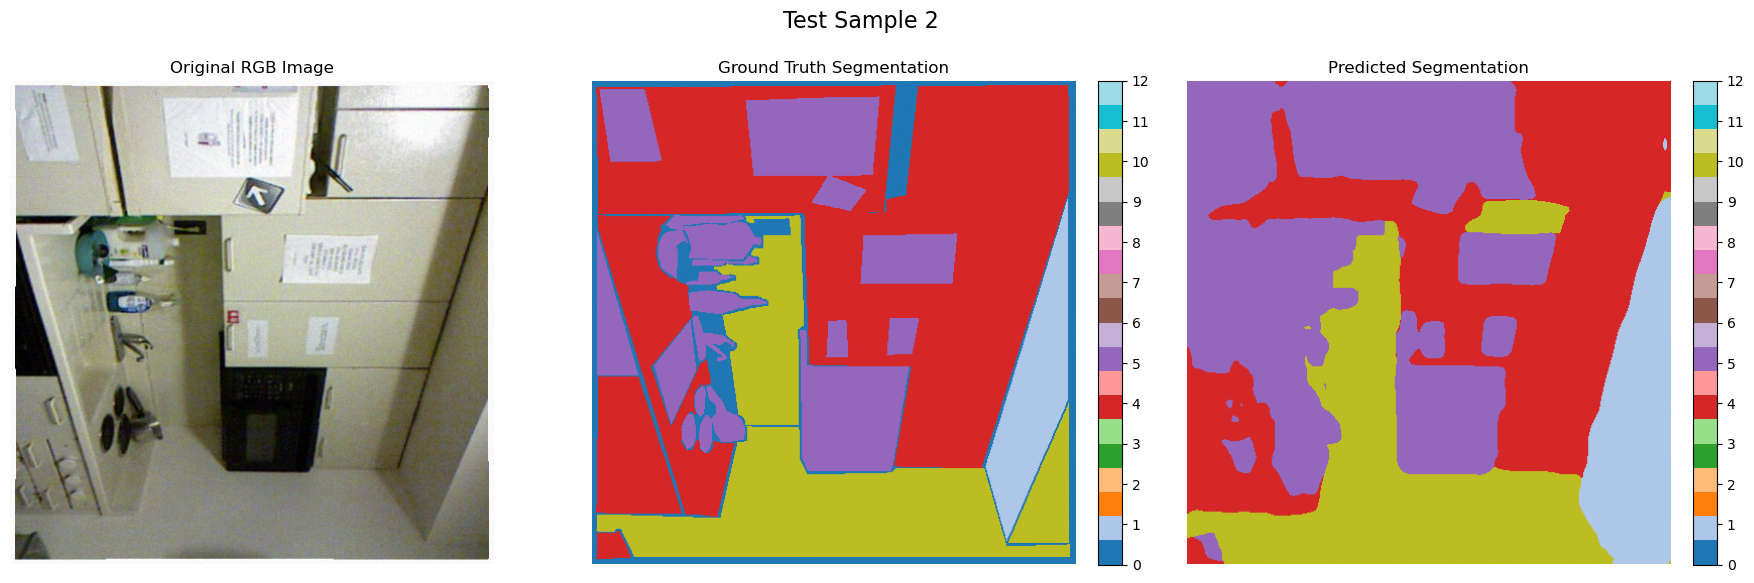

(4, 480, 480)


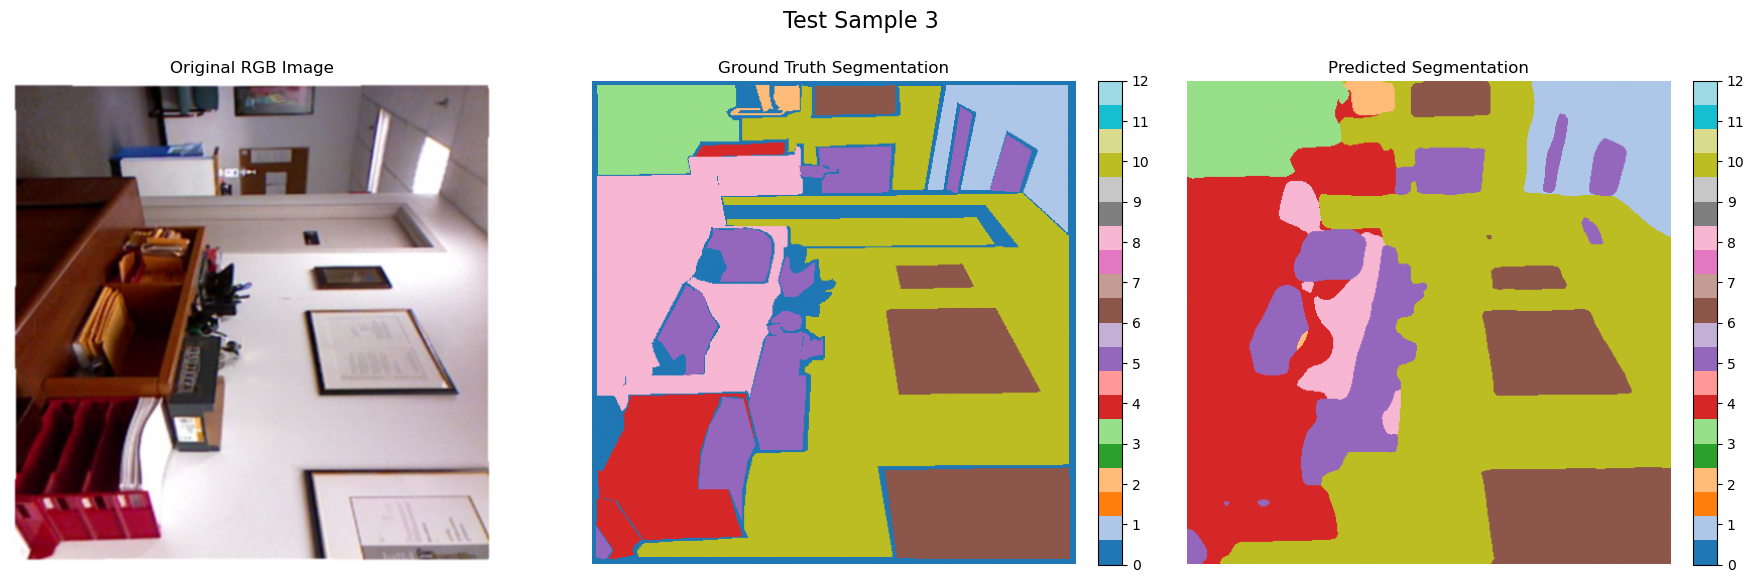

(4, 480, 480)


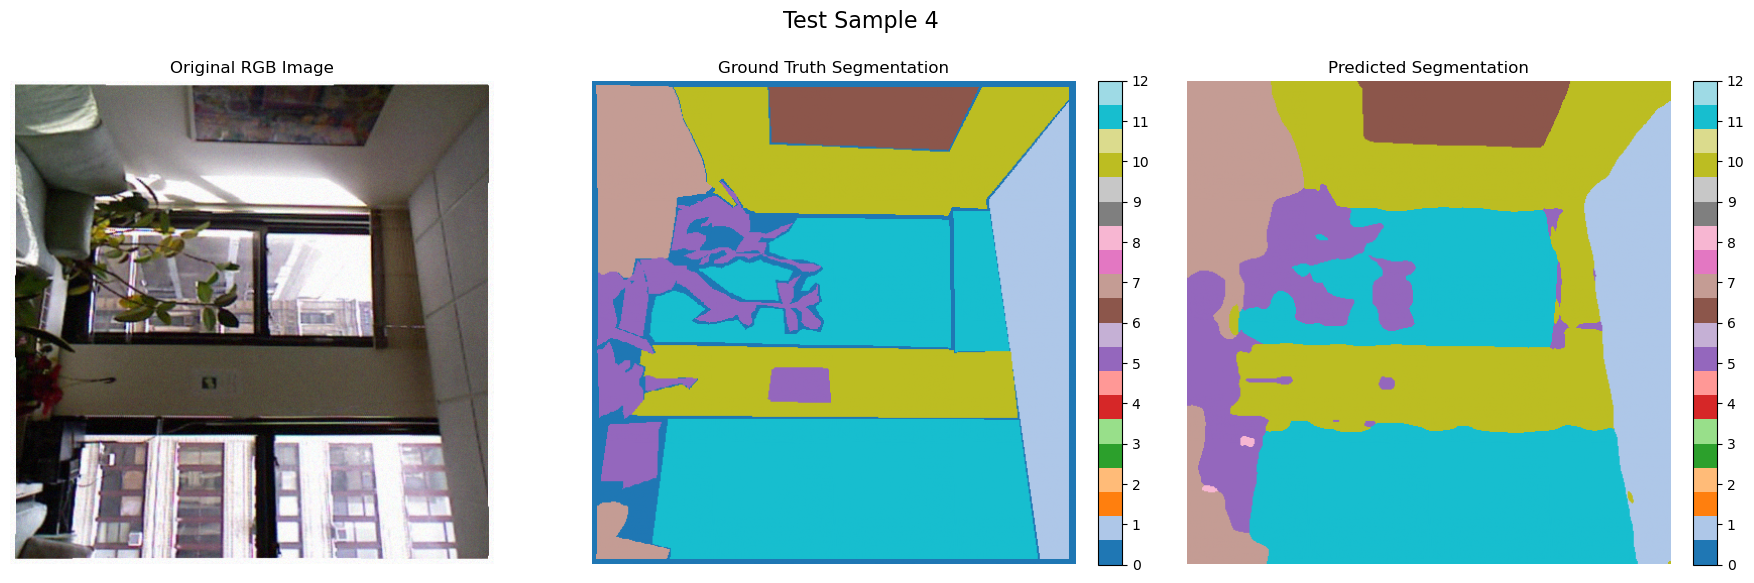


--- Test Results ---
Overall Test Accuracy: 0.7580
Overall Test mIoU: 0.5874
Testing complete.


In [18]:
# --- Test the trained model ---
print("\n--- Running Test Model ---")
# You can use val_loader as a proxy for a test set for this example
test_model(
    model=modelRaw,
    test_dataloader=test_loader, # Using test loader for demonstration
    num_classes=NUM_CLASSES,
    device=device,
    model_load_path=model_save_path,
    visualize_samples=BATCH_SIZE, # Visualize 2 samples from the test set
    PD_ToTrain = DepthConstSet().raw,
    RGB_ToTrain=True
)
